### 자연어 처리 : 문서 분류 개발 파이프라인

이 노트북은 **`문서 분류` 개발 파이프라인 예제 실습**을 수행하는 노트북입니다.

##### KoBART를 활용한 텍스트 요약 개발 파이프라인 예제
   1.  문서 분류 모델 Fine-tuning 및 저장 (Cell 11개)
   2.  Fine-tuning 한 문서 분류 모델 성능 평가 (Cell 11개)

   

### 01. 문서 분류 모델 Fine-tuning 및 저장

KLUE-BERT 모델(`klue/bert-base`)을 한국 청와대 국민청원 데이터셋(`heegyu/korean-petitions`)으로 Fine-tuning하여 

청원 내용을 자동으로 카테고리 별로 분류합니다.

LoRA 기법을 활용하여 효율적으로 한국어 텍스트 분류 모델을 구축하고 학습 과정을 시각화합니다.

* 한국어 청원 데이터셋 로드 및 텍스트 전처리 (제목과 내용 결합)
* KLUE-BERT 모델 로드 및 LoRA 설정으로 효율적인 Fine-tuning 환경 구성
* 데이터 분포 분석 및 학습/검증/테스트 세트 분할
* 모델 학습 실행 및 성능 지표 모니터링
* 학습 과정 시각화 및 최종 모델 저장

In [1]:
# ============================================
# Cell 1: 환경 설정 및 라이브러리 임포트
# ============================================

# 한국 청와대 국민청원 데이터를 사용하여
# 청원 내용을 자동으로 카테고리별로 분류하는 모델을 학습시킵니다.

# 필요한 라이브러리 import
import torch  # PyTorch: 딥러닝 프레임워크
import numpy as np  # NumPy: 수치 연산 라이브러리
import pandas as pd  # Pandas: 데이터 처리 라이브러리
from datasets import load_dataset, Dataset, DatasetDict  # HuggingFace 데이터셋 도구
from transformers import (
    AutoTokenizer,  # 텍스트를 토큰으로 변환하는 도구
    AutoModelForSequenceClassification,  # 텍스트 분류용 모델
    TrainingArguments,  # 학습 관련 설정
    Trainer,  # 모델 학습을 관리하는 클래스
    DataCollatorWithPadding  # 배치 데이터 패딩 처리
)
from peft import LoraConfig, get_peft_model, TaskType  # LoRA: 효율적인 파인튜닝 방법
from sklearn.model_selection import train_test_split  # 데이터 분할 도구
from sklearn.metrics import accuracy_score, precision_recall_fscore_support  # 성능 평가 지표
import matplotlib.pyplot as plt  # 그래프 그리기
import seaborn as sns  # 고급 시각화
from collections import Counter  # 빈도 계산
import json  # JSON 파일 처리
import time  # 시간 측정
from tqdm import tqdm  # 진행률 표시
import warnings
warnings.filterwarnings('ignore')  # 불필요한 경고 메시지 숨기기

# 한글 폰트 설정 (그래프에서 한글이 깨지지 않도록)
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'  # 윈도우
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'  # 맥
else:
    plt.rcParams['font.family'] = 'NanumGothic'  # 리눅스
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

print("라이브러리 임포트 완료!")


라이브러리 임포트 완료!


In [2]:
# ============================================
# Cell 2: GPU 설정 및 학습 파라미터 설정
# ============================================

# GPU 사용 가능 여부 확인
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

print("\n" + "="*50)
print("빠른 학습을 위한 설정")
print("="*50)

# ==================== 중요 설정 ====================
# 이 부분을 조정하여 학습 속도와 성능을 제어할 수 있습니다

SAMPLE_RATIO = 0.1  # 전체 데이터의 몇 %를 사용할지 (0.1 = 10%)
# 처음 테스트할 때: 0.05 (5%) - 약 10-20분
# 실제 학습할 때: 0.5 (50%) - 약 1-2시간  
# 최고 성능을 원할 때: 1.0 (100%) - 약 3-4시간

EPOCHS = 2  # 전체 데이터를 몇 번 반복 학습할지
# 1: 빠른 테스트용
# 3-5: 일반적인 학습
# 10: 최고 성능 (과적합 주의)

BATCH_SIZE = 16 if torch.cuda.is_available() else 8  # 한 번에 처리할 데이터 수
# GPU 메모리 부족 오류 시: 8 또는 4로 줄이기
# 강력한 GPU 사용 시: 32 또는 64로 늘리기

LEARNING_RATE = 3e-5  # 학습률 (너무 크면 발산, 너무 작으면 학습 안됨)
MAX_LENGTH = 512  # 텍스트 최대 길이 (BERT의 한계)

print(f"샘플링 비율: {SAMPLE_RATIO*100}%")
print(f"에폭 수: {EPOCHS}")
print(f"배치 크기: {BATCH_SIZE}")
print(f"최대 텍스트 길이: {MAX_LENGTH}")

Device: cuda
GPU: NVIDIA GeForce RTX 5090
GPU Memory: 31.8 GB

빠른 학습을 위한 설정
샘플링 비율: 10.0%
에폭 수: 2
배치 크기: 16
최대 텍스트 길이: 512


In [3]:
# ============================================
# Cell 3: 데이터 로드 및 전처리
# ============================================

print("\n" + "="*50)
print("1. 데이터 로드 및 전처리")
print("="*50)

# 데이터 로드
start_time = time.time()
print("데이터를 로드하는 중...")

# HuggingFace에서 한국 청원 데이터셋 다운로드
# 처음 실행 시 인터넷에서 다운로드하므로 시간이 걸립니다
dataset = load_dataset("heegyu/korean-petitions")
df = pd.DataFrame(dataset['train'])  # 데이터프레임으로 변환
original_size = len(df)

# 샘플링 (빠른 테스트를 위해 일부만 사용)
if SAMPLE_RATIO < 1.0:
    df = df.sample(frac=SAMPLE_RATIO, random_state=42)  # random_state로 재현성 보장
    print(f"샘플링 완료: {original_size:,}개 → {len(df):,}개 ({SAMPLE_RATIO*100}%)")
else:
    print(f"전체 데이터 사용: {len(df):,}개")

# 카테고리 분석
# 청원 카테고리를 추출하고 정렬
categories = sorted(df['category'].unique())
# 카테고리를 숫자로 매핑 (예: "일자리" → 0, "교육" → 1)
category_to_id = {cat: idx for idx, cat in enumerate(categories)}
# 역매핑 (숫자 → 카테고리)
id_to_category = {idx: cat for cat, idx in category_to_id.items()}

print(f"\n총 {len(categories)}개 카테고리 발견")
print("주요 카테고리:", ", ".join(categories[:5]), "...")

# 텍스트 전처리
print("\n텍스트 전처리 중...")
# 제목과 내용을 [SEP] 토큰으로 연결
# BERT는 [SEP]로 두 개의 문장을 구분할 수 있습니다
df['text'] = df.apply(lambda row: f"{row['title']} [SEP] {row['content']}", axis=1)
# 카테고리를 숫자 레이블로 변환
df['label'] = df['category'].map(category_to_id)

# 텍스트 길이 분석 (너무 긴 텍스트는 잘림)
df['text_length'] = df['text'].str.len()
print(f"평균 텍스트 길이: {df['text_length'].mean():.0f}자")
print(f"최대 텍스트 길이: {df['text_length'].max():.0f}자")

# 데이터 샘플 확인
print("\n=== 데이터 샘플 ===")
sample = df.iloc[0]
print(f"카테고리: {sample['category']}")
print(f"제목: {sample['title'][:50]}...")
print(f"내용: {sample['content'][:100]}...")


1. 데이터 로드 및 전처리
데이터를 로드하는 중...


Resolving data files:   0%|          | 0/25 [00:00<?, ?it/s]

샘플링 완료: 436,660개 → 43,666개 (10.0%)

총 17개 카테고리 발견
주요 카테고리: 경제민주화, 교통/건축/국토, 기타, 농산어촌, 문화/예술/체육/언론 ...

텍스트 전처리 중...
평균 텍스트 길이: 583자
최대 텍스트 길이: 1655691자

=== 데이터 샘플 ===
카테고리: 기타
제목: 나경원 평창 올림픽 위원 자격 박탈해주세요....
내용: 언제까지 북한을 이용해서 국민을 이간질 시키려합니까.. 축제인 올림픽을 위원장이 평양올림픽이니 그런 말로 분위기를 흐리고 있습니다....



2. 데이터 분포 시각화


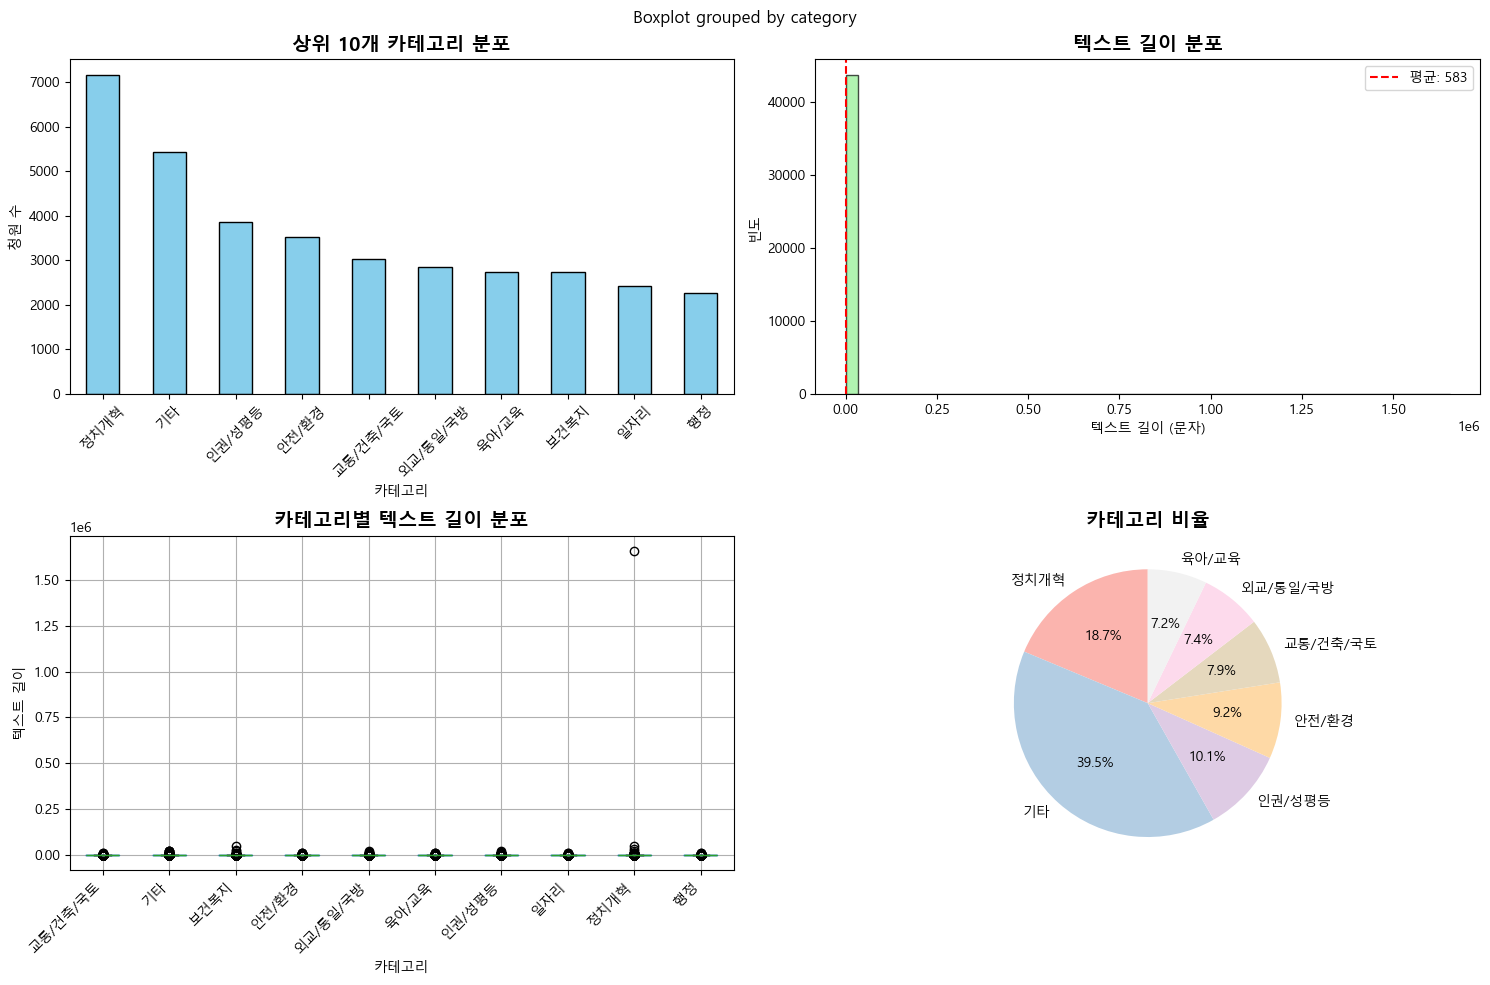

In [4]:
# ============================================
# Cell 4: 데이터 분포 시각화
# ============================================

print("\n" + "="*50)
print("2. 데이터 분포 시각화")
print("="*50)

# 4개의 서브플롯으로 데이터 특성 시각화
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. 카테고리별 분포 (상위 10개)
ax1 = axes[0, 0]
category_counts = df['category'].value_counts()
top_categories = category_counts.head(10)
top_categories.plot(kind='bar', ax=ax1, color='skyblue', edgecolor='black')
ax1.set_title('상위 10개 카테고리 분포', fontsize=14, fontweight='bold')
ax1.set_xlabel('카테고리')
ax1.set_ylabel('청원 수')
ax1.tick_params(axis='x', rotation=45)
# 이 그래프로 어떤 주제의 청원이 많은지 확인할 수 있습니다

# 2. 텍스트 길이 분포
ax2 = axes[0, 1]
ax2.hist(df['text_length'], bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
ax2.axvline(df['text_length'].mean(), color='red', linestyle='--', 
            label=f'평균: {df["text_length"].mean():.0f}')
ax2.set_title('텍스트 길이 분포', fontsize=14, fontweight='bold')
ax2.set_xlabel('텍스트 길이 (문자)')
ax2.set_ylabel('빈도')
ax2.legend()
# 대부분의 청원이 어느 정도 길이인지 파악 가능

# 3. 카테고리별 텍스트 길이 박스플롯
ax3 = axes[1, 0]
top_cats = category_counts.head(10).index
df_top = df[df['category'].isin(top_cats)]
df_top.boxplot(column='text_length', by='category', ax=ax3)
ax3.set_title('카테고리별 텍스트 길이 분포', fontsize=14, fontweight='bold')
ax3.set_xlabel('카테고리')
ax3.set_ylabel('텍스트 길이')
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')
# 특정 카테고리의 청원이 더 길거나 짧은 경향이 있는지 확인

# 4. 카테고리 비율 파이 차트
ax4 = axes[1, 1]
category_percentages = (category_counts / len(df) * 100).head(7)
others_percentage = 100 - category_percentages.sum()
if others_percentage > 0:
    category_percentages['기타'] = others_percentage

colors = plt.cm.Pastel1(np.linspace(0, 1, len(category_percentages)))
wedges, texts, autotexts = ax4.pie(category_percentages.values, 
                                    labels=category_percentages.index,
                                    autopct='%1.1f%%',
                                    colors=colors,
                                    startangle=90)
ax4.set_title('카테고리 비율', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [5]:
# ============================================
# Cell 5: 데이터 분할
# ============================================

print("\n" + "="*50)
print("3. 데이터 분할")
print("="*50)

# 데이터를 학습/검증/테스트로 분할
X = df['text'].values  # 입력 텍스트
y = df['label'].values  # 정답 레이블

# 15%를 테스트용으로 분리
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y  # stratify로 카테고리 비율 유지
)
# 나머지에서 17.65%를 검증용으로 분리 (전체의 15%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp
)

print(f"학습 데이터: {len(X_train):,}개 ({len(X_train)/len(X)*100:.1f}%)")
print(f"검증 데이터: {len(X_val):,}개 ({len(X_val)/len(X)*100:.1f}%)")
print(f"테스트 데이터: {len(X_test):,}개 ({len(X_test)/len(X)*100:.1f}%)")

# HuggingFace 데이터셋 형식으로 변환
# Trainer가 요구하는 형식에 맞춤
hf_dataset = DatasetDict({
    "train": Dataset.from_dict({"text": X_train, "labels": y_train}),
    "validation": Dataset.from_dict({"text": X_val, "labels": y_val}),
    "test": Dataset.from_dict({"text": X_test, "labels": y_test})
})

print("데이터 분할 완료!")


3. 데이터 분할
학습 데이터: 30,565개 (70.0%)
검증 데이터: 6,551개 (15.0%)
테스트 데이터: 6,550개 (15.0%)
데이터 분할 완료!


In [6]:
# ============================================
# Cell 6: 모델 및 토크나이저 로드
# ============================================

print("\n" + "="*50)
print("4. 모델 및 토크나이저 로드")
print("="*50)

# KLUE-BERT 모델 사용 (한국어에 특화된 BERT)
model_name = "klue/bert-base"
print(f"모델 로드 중: {model_name}")

# 토크나이저: 텍스트를 모델이 이해할 수 있는 토큰으로 변환
tokenizer = AutoTokenizer.from_pretrained(model_name)

# 분류 모델: BERT + 분류 레이어
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(categories),  # 출력 크기 = 카테고리 수
    problem_type="single_label_classification"  # 다중 클래스 분류
)

# LoRA 설정 (Low-Rank Adaptation)
# 전체 모델을 학습하지 않고 일부만 학습하여 효율성 극대화
print("\nLoRA 어댑터 설정 중...")
peft_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,  # 시퀀스 분류 태스크
    r=16,  # LoRA rank (낮을수록 빠르지만 성능 하락)
    lora_alpha=32,  # LoRA 스케일링 파라미터
    lora_dropout=0.1,  # 드롭아웃으로 과적합 방지
    target_modules=["query", "value", "key", "dense"],  # 적용할 레이어
    bias="none"  # 바이어스는 학습하지 않음
)

# LoRA 적용
model = get_peft_model(model, peft_config)
model.print_trainable_parameters()  # 학습 가능한 파라미터 수 출력

# GPU로 모델 이동
model = model.to(device)


4. 모델 및 토크나이저 로드
모델 로드 중: klue/bert-base


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at klue/bert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



LoRA 어댑터 설정 중...
trainable params: 2,691,857 || all params: 113,322,274 || trainable%: 2.3754


In [7]:
# ============================================
# Cell 7: 데이터 토크나이징
# ============================================

print("\n" + "="*50)
print("5. 데이터 토크나이징")
print("="*50)

# 토크나이징 함수 정의
def tokenize_function(examples):
    """텍스트를 토큰으로 변환하는 함수"""
    return tokenizer(
        examples["text"],
        truncation=True,  # 긴 텍스트 자르기
        max_length=MAX_LENGTH,  # 최대 길이
        padding=False  # 패딩은 나중에 동적으로 처리
    )

# 전체 데이터셋 토크나이징
print("토크나이징 진행 중...")
tokenized_dataset = hf_dataset.map(
    tokenize_function,
    batched=True,  # 배치 처리로 속도 향상
    num_proc=None,  # Windows에서는 멀티프로세싱 비활성화
    desc="Tokenizing"
)

# 데이터 콜레이터: 배치마다 동적으로 패딩 처리
data_collator = DataCollatorWithPadding(tokenizer=tokenizer, padding=True)

print("토크나이징 완료!")


5. 데이터 토크나이징
토크나이징 진행 중...


Tokenizing:   0%|          | 0/30565 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/6551 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/6550 [00:00<?, ? examples/s]

토크나이징 완료!


In [8]:
# ============================================
# Cell 8: 학습 설정 및 Trainer 초기화
# ============================================

print("\n" + "="*50)
print("6. 학습 설정")
print("="*50)

# 학습 관련 모든 설정
training_args = TrainingArguments(
    output_dir="./korean-petition-classifier",  # 체크포인트 저장 폴더
    num_train_epochs=EPOCHS,  # 전체 데이터 반복 횟수
    per_device_train_batch_size=BATCH_SIZE,  # 학습 배치 크기
    per_device_eval_batch_size=BATCH_SIZE * 2,  # 평가는 더 큰 배치 가능
    warmup_steps=500,  # 학습률을 천천히 올리는 스텝 수
    weight_decay=0.01,  # 가중치 정규화 (과적합 방지)
    learning_rate=LEARNING_RATE,  # 초기 학습률
    logging_dir='./logs',  # 로그 저장 위치
    logging_steps=10,  # 10스텝마다 로그 기록
    eval_strategy="steps",  # 스텝 단위로 평가
    eval_steps=100,  # 100스텝마다 평가
    save_strategy="steps",  # 스텝 단위로 저장
    save_steps=200,  # 200스텝마다 체크포인트 저장
    save_total_limit=2,  # 최대 2개의 체크포인트만 유지
    load_best_model_at_end=True,  # 최고 성능 모델 로드
    metric_for_best_model="eval_loss",  # 검증 손실 기준
    greater_is_better=False,  # 손실은 낮을수록 좋음
    fp16=True if torch.cuda.is_available() else False,  # 16비트 연산 (속도 향상)
    gradient_checkpointing=True,  # 메모리 절약 기법
    report_to="none",  # wandb 등 외부 로깅 비활성화
    seed=42,  # 재현성을 위한 시드 고정
)

# 평가 지표 계산 함수
def compute_metrics(eval_pred):
    """정확도, 정밀도, 재현율, F1 점수 계산"""
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)  # 가장 높은 확률의 클래스 선택
    
    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='weighted', zero_division=0
    )
    
    return {
        'accuracy': accuracy,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

# 학습 과정을 기록할 딕셔너리
training_history = {
    'loss': [],
    'eval_loss': [],
    'eval_accuracy': [],
    'eval_f1': [],
    'learning_rate': [],
    'epoch': []
}

# 커스텀 콜백: 학습 과정 기록
from transformers import TrainerCallback

class VisualizationCallback(TrainerCallback):
    """학습 중 발생하는 지표들을 기록하는 콜백"""
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs is not None:
            # 각 지표를 해당 리스트에 추가
            if 'loss' in logs:
                training_history['loss'].append(logs['loss'])
            if 'eval_loss' in logs:
                training_history['eval_loss'].append(logs['eval_loss'])
            if 'eval_accuracy' in logs:
                training_history['eval_accuracy'].append(logs['eval_accuracy'])
            if 'eval_f1' in logs:
                training_history['eval_f1'].append(logs['eval_f1'])
            if 'learning_rate' in logs:
                training_history['learning_rate'].append(logs['learning_rate'])
            if 'epoch' in logs:
                training_history['epoch'].append(logs['epoch'])

# Trainer 초기화
trainer = Trainer(
    model=model,  # 학습할 모델
    args=training_args,  # 학습 설정
    data_collator=data_collator,  # 데이터 콜레이터
    train_dataset=tokenized_dataset["train"],  # 학습 데이터
    eval_dataset=tokenized_dataset["validation"],  # 검증 데이터
    tokenizer=tokenizer,  # 토크나이저
    compute_metrics=compute_metrics,  # 평가 함수
    callbacks=[VisualizationCallback()]  # 커스텀 콜백
)

print("Trainer 초기화 완료!")

No label_names provided for model class `PeftModelForSequenceClassification`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.



6. 학습 설정
Trainer 초기화 완료!


In [9]:
# ============================================
# Cell 9: 모델 학습 실행
# ============================================

print("\n" + "="*50)
print("7. 모델 학습")
print("="*50)

# 예상 학습 시간 계산
total_steps = len(tokenized_dataset["train"]) // BATCH_SIZE * EPOCHS
print(f"총 학습 스텝: {total_steps:,}")
print(f"예상 소요 시간: ", end="")
if torch.cuda.is_available():
    if SAMPLE_RATIO <= 0.05:
        print("10-30분")
    elif SAMPLE_RATIO <= 0.1:
        print("20-60분")
    else:
        print("1-3시간")
else:
    print("CPU 환경에서는 매우 오래 걸립니다!")

print("\n학습을 시작합니다...")
start_train_time = time.time()

# 실제 학습 실행!
train_result = trainer.train()

# 학습 시간 측정
train_time = time.time() - start_train_time
print(f"\n학습 완료! 소요 시간: {train_time/60:.1f}분")


7. 모델 학습
총 학습 스텝: 3,820
예상 소요 시간: 20-60분

학습을 시작합니다...


Step,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
100,3.016600,2.974326,0.051443,0.016246,0.098562,0.051443
200,2.845000,2.844877,0.090063,0.044655,0.098952,0.090063
300,2.686500,2.672479,0.131125,0.072644,0.078762,0.131125
400,2.633700,2.592375,0.163639,0.054222,0.069547,0.163639
500,2.492700,2.551412,0.172798,0.068456,0.100702,0.172798
600,2.525000,2.527684,0.184247,0.085754,0.104894,0.184247
700,2.479500,2.508205,0.193406,0.089366,0.122729,0.193406
800,2.457200,2.490908,0.195390,0.093957,0.120989,0.195390
900,2.471600,2.474566,0.205007,0.111096,0.121226,0.205007
1000,2.510800,2.461375,0.208212,0.114105,0.154750,0.208212



학습 완료! 소요 시간: 9.7분



8. 학습 과정 시각화


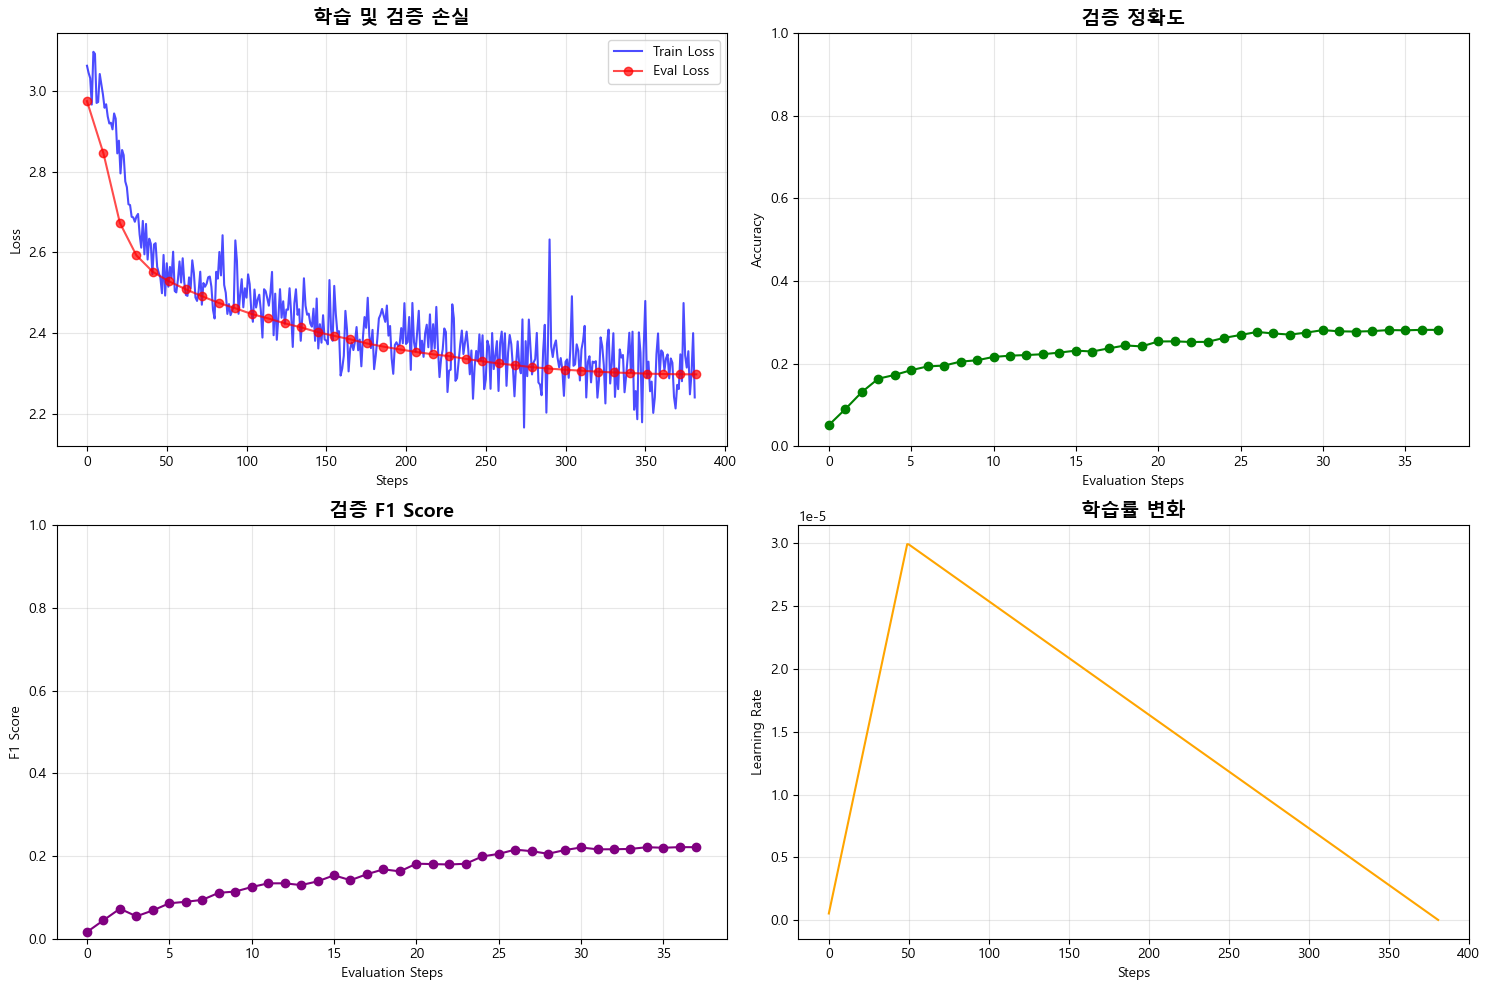

In [10]:
# ============================================
# Cell 10: 학습 과정 시각화
# ============================================

print("\n" + "="*50)
print("8. 학습 과정 시각화")
print("="*50)

# 학습 과정을 4개의 그래프로 시각화
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Loss 그래프 (학습 손실과 검증 손실)
ax1 = axes[0, 0]
if training_history['loss']:
    ax1.plot(training_history['loss'], label='Train Loss', color='blue', alpha=0.7)
if training_history['eval_loss']:
    # 검증은 일정 스텝마다 수행되므로 x축 조정
    eval_steps = np.linspace(0, len(training_history['loss']), len(training_history['eval_loss']))
    ax1.plot(eval_steps, training_history['eval_loss'], label='Eval Loss', color='red', alpha=0.7, marker='o')
ax1.set_title('학습 및 검증 손실', fontsize=14, fontweight='bold')
ax1.set_xlabel('Steps')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)
# 손실이 감소하면 모델이 학습되고 있음을 의미

# 2. 정확도 그래프
ax2 = axes[0, 1]
if training_history['eval_accuracy']:
    ax2.plot(training_history['eval_accuracy'], marker='o', color='green')
    ax2.set_title('검증 정확도', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Evaluation Steps')
    ax2.set_ylabel('Accuracy')
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(0, 1)
# 정확도가 증가하면 성능이 향상되고 있음

# 3. F1 Score 그래프
ax3 = axes[1, 0]
if training_history['eval_f1']:
    ax3.plot(training_history['eval_f1'], marker='o', color='purple')
    ax3.set_title('검증 F1 Score', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Evaluation Steps')
    ax3.set_ylabel('F1 Score')
    ax3.grid(True, alpha=0.3)
    ax3.set_ylim(0, 1)
# F1은 정밀도와 재현율의 조화평균

# 4. 학습률 변화 그래프
ax4 = axes[1, 1]
if training_history['learning_rate']:
    ax4.plot(training_history['learning_rate'], color='orange')
    ax4.set_title('학습률 변화', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Steps')
    ax4.set_ylabel('Learning Rate')
    ax4.grid(True, alpha=0.3)
    ax4.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
# 학습률은 보통 감소하도록 설정

plt.tight_layout()
plt.show()

In [11]:
# ============================================
# Cell 11: 모델 저장 및 요약
# ============================================

print("\n" + "="*50)
print("9. 모델 저장")
print("="*50)

# 학습된 모델 저장
output_dir = "./best-korean-petition-classifier"
trainer.save_model(output_dir)  # 모델 가중치 저장
tokenizer.save_pretrained(output_dir)  # 토크나이저 저장

# 카테고리 정보 저장 (나중에 예측할 때 필요)
category_info = {
    "category_to_id": category_to_id,  # 카테고리 → 숫자
    "id_to_category": id_to_category,  # 숫자 → 카테고리
    "categories": categories  # 전체 카테고리 목록
}

with open(f"{output_dir}/category_info.json", "w", encoding="utf-8") as f:
    json.dump(category_info, f, ensure_ascii=False, indent=2)

# 학습 정보 저장 (나중에 참고용)
training_info = {
    "model_name": model_name,
    "sample_ratio": SAMPLE_RATIO,
    "total_samples": len(df),
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "max_length": MAX_LENGTH,
    "train_time_minutes": train_time / 60,
    "num_categories": len(categories),
    "train_samples": len(X_train),
    "val_samples": len(X_val),
    "test_samples": len(X_test)
}

with open(f"{output_dir}/training_info.json", "w", encoding="utf-8") as f:
    json.dump(training_info, f, ensure_ascii=False, indent=2)

print(f"모델이 저장되었습니다: {output_dir}")
print(f"  - 모델 파일")
print(f"  - 토크나이저")
print(f"  - 카테고리 정보 (category_info.json)")
print(f"  - 학습 정보 (training_info.json)")

print("\n" + "="*50)
print("10. 학습 요약")
print("="*50)

# 학습 결과 요약 출력
print(f"""
학습 결과 요약:
----------------------------------------
- 사용 데이터: {len(df):,}개 ({SAMPLE_RATIO*100}%)
- 학습 시간: {train_time/60:.1f}분
- 카테고리 수: {len(categories)}개
- 학습 샘플: {len(X_train):,}개
- 검증 샘플: {len(X_val):,}개
- 테스트 샘플: {len(X_test):,}개
----------------------------------------

성능 향상을 위한 제안:
1. SAMPLE_RATIO를 높여서 더 많은 데이터 사용
2. EPOCHS를 3-5로 늘려서 충분한 학습
3. 클래스 불균형이 심한 카테고리에 가중치 부여
4. 더 큰 LoRA rank 사용 (r=32 또는 64)
""")

# GPU 메모리 정리
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("\n모든 작업이 완료되었습니다!")


9. 모델 저장
모델이 저장되었습니다: ./best-korean-petition-classifier
  - 모델 파일
  - 토크나이저
  - 카테고리 정보 (category_info.json)
  - 학습 정보 (training_info.json)

10. 학습 요약

학습 결과 요약:
----------------------------------------
- 사용 데이터: 43,666개 (10.0%)
- 학습 시간: 9.7분
- 카테고리 수: 17개
- 학습 샘플: 30,565개
- 검증 샘플: 6,551개
- 테스트 샘플: 6,550개
----------------------------------------

성능 향상을 위한 제안:
1. SAMPLE_RATIO를 높여서 더 많은 데이터 사용
2. EPOCHS를 3-5로 늘려서 충분한 학습
3. 클래스 불균형이 심한 카테고리에 가중치 부여
4. 더 큰 LoRA rank 사용 (r=32 또는 64)


모든 작업이 완료되었습니다!


### 02. Fine-tuning 한 문서 분류 모델 성능 평가

한국 청와대 국민청원 데이터 셋이 학습된 KLUE-BERT 기반 Fine-tuned 모델(`./best-korean-petition-classifier`)의 성능을 종합적으로 평가합니다.

테스트 데이터셋을 사용하여 정확도, 정밀도, 재현율, F1 점수 등 다양한 성능 지표를 계산하고, 

혼동 행렬과 오분류 분석을 통해 모델의 강점과 약점을 시각화합니다.

* 학습된 모델 및 카테고리 정보 로드
* 테스트 데이터 준비 및 배치 예측 함수 정의
* 전체 성능 지표 계산 (정확도, 정밀도, 재현율, F1 점수)
* 혼동 행렬, 신뢰도 분포 등 다양한 시각화
* 오분류 패턴 분석 및 카테고리별 상세 성능 분석

In [23]:
# ============================================
# Cell 1: 환경 설정 및 라이브러리 임포트
# ============================================

# 학습된 청원 분류 모델의 성능을 평가합니다.

# 필요한 라이브러리 import
import torch  # PyTorch 딥러닝 프레임워크
import numpy as np  # 수치 연산
import pandas as pd  # 데이터 처리
from tqdm import tqdm  # 진행률 표시 (예측 중 진행 상황을 보여줌)
import matplotlib.pyplot as plt  # 그래프 그리기
import seaborn as sns  # 고급 시각화 (히트맵 등)
from sklearn.metrics import (  # scikit-learn의 평가 지표들
    accuracy_score,  # 정확도: 전체 중 맞춘 비율
    precision_recall_fscore_support,  # 정밀도, 재현율, F1 점수
    confusion_matrix,  # 혼동 행렬: 실제 vs 예측 비교
    classification_report,  # 카테고리별 상세 성능
    f1_score  # F1 점수 개별 계산용
)
from transformers import (
    AutoTokenizer,  # 텍스트를 토큰으로 변환
    AutoModelForSequenceClassification  # 분류 모델
)
from peft import PeftModel  # LoRA 모델 로드용
from datasets import load_dataset  # 데이터셋 로드
import json  # JSON 파일 처리
import warnings
warnings.filterwarnings('ignore')  # 불필요한 경고 숨기기

# Transformers 라이브러리의 경고 메시지 레벨 설정
import logging
logging.getLogger("transformers").setLevel(logging.ERROR)

# 한글 폰트 설정 (그래프에서 한글이 깨지지 않도록)
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# scipy import (상관계수 계산용) - 없어도 작동하도록 예외 처리
try:
    from scipy.stats import pearsonr  # 피어슨 상관계수 계산
except ImportError:
    pearsonr = None  # scipy가 없으면 None으로 설정

print("라이브러리 임포트 완료!")

라이브러리 임포트 완료!


In [24]:
# ============================================
# Cell 2: GPU 설정 및 모델/데이터셋 로드
# ============================================

# GPU 사용 가능 여부 확인
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

print("\n" + "="*50)
print("1. 모델 및 설정 로드")
print("="*50)

# 모델이 저장된 경로
model_path = "./best-korean-petition-classifier"
base_model_name = "klue/bert-base"  # 기본 모델 이름

# 카테고리 정보 로드
# 학습 시 저장한 카테고리 매핑 정보를 불러옴
try:
    with open(f"{model_path}/category_info.json", "r", encoding="utf-8") as f:
        category_info = json.load(f)
    category_to_id = category_info["category_to_id"]  # 카테고리 → 숫자
    id_to_category = {str(k): v for k, v in category_info["id_to_category"].items()}  # 숫자 → 카테고리
    categories = category_info["categories"]  # 전체 카테고리 목록
    print(f"카테고리 정보를 로드했습니다. (총 {len(categories)}개 카테고리)")
except Exception as e:
    # 카테고리 정보가 없으면 데이터셋에서 직접 추출
    print(f"카테고리 정보 로드 실패: {e}")
    print("데이터셋에서 카테고리 정보를 추출합니다...")
    dataset = load_dataset("heegyu/korean-petitions")
    categories = sorted(list(set([item['category'] for item in dataset['train']])))
    category_to_id = {cat: idx for idx, cat in enumerate(categories)}
    id_to_category = {str(idx): cat for idx, cat in enumerate(categories)}

# 학습 정보 로드
# 학습 시 사용한 설정들을 확인
try:
    with open(f"{model_path}/training_info.json", "r", encoding="utf-8") as f:
        training_info = json.load(f)
    print(f"\n학습 정보:")
    print(f"  - 사용 데이터: {training_info['total_samples']:,}개 ({training_info['sample_ratio']*100}%)")
    print(f"  - 학습 시간: {training_info['train_time_minutes']:.1f}분")
    print(f"  - 에폭: {training_info['epochs']}")
except:
    print("학습 정보를 불러올 수 없습니다.")
    training_info = {}

# 카테고리 목록 출력 (일부만)
print(f"\n청원 카테고리 목록 (일부):")
for i, category in enumerate(categories[:10]):
    print(f"  {i}: {category}")
if len(categories) > 10:
    print(f"  ... 그 외 {len(categories)-10}개 카테고리")

# 토크나이저 로드
# 텍스트를 모델이 이해할 수 있는 형태로 변환하는 도구
try:
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    print(f"\nFine-tuned 모델의 토크나이저를 로드했습니다.")
except:
    tokenizer = AutoTokenizer.from_pretrained(base_model_name)
    print(f"\nBase 모델의 토크나이저를 로드했습니다.")

# 모델 로드
# 학습된 가중치를 가진 모델을 불러옴
try:
    # LoRA 어댑터가 포함된 모델 로드 시도
    model = AutoModelForSequenceClassification.from_pretrained(
        base_model_name,
        num_labels=len(categories)
    )
    model = PeftModel.from_pretrained(model, model_path)  # LoRA 어댑터 로드
    model = model.merge_and_unload()  # LoRA 가중치를 기본 모델에 병합
    print(f"Fine-tuned LoRA 모델을 로드했습니다: {model_path}")
except:
    try:
        # 일반 모델로 로드 시도
        model = AutoModelForSequenceClassification.from_pretrained(
            model_path,
            num_labels=len(categories)
        )
        print(f"Fine-tuned 모델을 로드했습니다: {model_path}")
    except:
        # 모델을 찾을 수 없으면 기본 모델 사용
        print(f"Fine-tuned 모델을 찾을 수 없어 base 모델을 로드합니다: {base_model_name}")
        model = AutoModelForSequenceClassification.from_pretrained(
            base_model_name,
            num_labels=len(categories)
        )

# 모델을 GPU/CPU로 이동하고 평가 모드로 설정
model = model.to(device)
model.eval()  # 평가 모드: 드롭아웃 비활성화, 그래디언트 계산 안함

Device: cuda

1. 모델 및 설정 로드
카테고리 정보를 로드했습니다. (총 17개 카테고리)

학습 정보:
  - 사용 데이터: 43,666개 (10.0%)
  - 학습 시간: 9.7분
  - 에폭: 2

청원 카테고리 목록 (일부):
  0: 경제민주화
  1: 교통/건축/국토
  2: 기타
  3: 농산어촌
  4: 문화/예술/체육/언론
  5: 미래
  6: 반려동물
  7: 보건복지
  8: 성장동력
  9: 안전/환경
  ... 그 외 7개 카테고리

Fine-tuned 모델의 토크나이저를 로드했습니다.
Fine-tuned LoRA 모델을 로드했습니다: ./best-korean-petition-classifier


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(32000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [25]:
# ============================================
# Cell 3: 테스트 데이터 준비
# ============================================

print("\n" + "="*50)
print("2. 테스트 데이터 준비")
print("="*50)

# 실제 청원 데이터 로드
print("실제 청원 데이터를 로드합니다...")
dataset = load_dataset("heegyu/korean-petitions")
df = pd.DataFrame(dataset['train'])

# 학습 시와 동일한 샘플링 비율 적용
# 공정한 평가를 위해 학습 때와 같은 데이터 부분집합 사용
try:
    sample_ratio = training_info['sample_ratio']
except:
    sample_ratio = 1.0  # 기본값: 전체 데이터

# 샘플링 적용
if sample_ratio < 1.0:
    df = df.sample(frac=sample_ratio, random_state=42)  # 동일한 시드로 재현성 보장
    print(f"학습 시와 동일한 샘플링 적용: {len(df):,}개 ({sample_ratio*100}%)")

# 데이터 전처리 (학습 때와 동일하게)
df['text'] = df.apply(lambda row: f"{row['title']} [SEP] {row['content']}", axis=1)
df['label'] = df['category'].map(category_to_id)

# 테스트 세트 분리 (학습 코드와 완전히 동일한 방식)
from sklearn.model_selection import train_test_split
X = df['text'].values
y = df['label'].values

# 동일한 random_state로 학습 때와 같은 분할 재현
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

print(f"테스트 데이터: {len(X_test):,}개")

# 테스트 데이터의 카테고리 분포 확인
test_category_dist = pd.Series(y_test).value_counts().sort_index()
print("\n테스트 데이터 카테고리 분포 (상위 10개):")
for idx, count in test_category_dist.head(10).items():
    print(f"  {id_to_category[str(idx)]}: {count}개")


2. 테스트 데이터 준비
실제 청원 데이터를 로드합니다...


Resolving data files:   0%|          | 0/25 [00:00<?, ?it/s]

학습 시와 동일한 샘플링 적용: 43,666개 (10.0%)
테스트 데이터: 6,550개

테스트 데이터 카테고리 분포 (상위 10개):
  경제민주화: 263개
  교통/건축/국토: 454개
  기타: 814개
  농산어촌: 30개
  문화/예술/체육/언론: 302개
  미래: 306개
  반려동물: 65개
  보건복지: 410개
  성장동력: 123개
  안전/환경: 528개


In [26]:
# ============================================
# Cell 4: 예측 함수 정의
# ============================================

print("\n" + "="*50)
print("3. 예측 함수 정의")
print("="*50)

def predict_category(text, return_probs=False):
    """
    단일 청원의 카테고리를 예측하는 함수
    
    Parameters:
    - text: 분류할 청원 텍스트
    - return_probs: True면 모든 카테고리의 확률도 반환
    
    Returns:
    - predicted_category: 예측된 카테고리 이름
    - confidence: 예측 신뢰도 (0~1)
    - all_probs: (선택) 모든 카테고리의 확률 딕셔너리
    """
    # numpy array나 다른 타입인 경우 string으로 변환
    if not isinstance(text, str):
        text = str(text)
    
    # 텍스트를 토큰으로 변환
    inputs = tokenizer(
        text,
        truncation=True,  # 긴 텍스트 자르기
        padding=True,  # 패딩 추가
        max_length=512,  # 최대 길이
        return_tensors="pt"  # PyTorch 텐서로 반환
    )
    
    # 입력을 GPU/CPU로 이동
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    # 예측 (그래디언트 계산 안함)
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits  # 모델의 원시 출력값
        probs = torch.nn.functional.softmax(logits, dim=-1)  # 확률로 변환
        
        # 가장 높은 확률의 카테고리 선택
        predicted_class = torch.argmax(probs, dim=-1).item()
        confidence = probs[0][predicted_class].item()
    
    # 숫자를 카테고리 이름으로 변환
    predicted_category = id_to_category[str(predicted_class)]
    
    if return_probs:
        # 모든 카테고리의 확률 반환
        all_probs = {id_to_category[str(i)]: probs[0][i].item() for i in range(len(categories))}
        return predicted_category, confidence, all_probs
    
    return predicted_category, confidence

def batch_predict(texts, batch_size=16):
    """
    여러 청원을 배치로 처리하여 예측하는 함수
    배치 처리로 속도를 크게 향상시킬 수 있음
    
    Parameters:
    - texts: 청원 텍스트 리스트
    - batch_size: 한 번에 처리할 텍스트 수
    
    Returns:
    - predictions: 예측된 카테고리 인덱스 리스트
    - confidences: 신뢰도 리스트
    - all_probs: 모든 확률 배열
    """
    predictions = []
    confidences = []
    all_probs = []
    
    # 배치 단위로 처리
    for i in tqdm(range(0, len(texts), batch_size), desc="Predicting"):
        batch_texts = list(texts[i:i+batch_size])  # numpy array를 list로 변환
        
        # 배치 토크나이징
        inputs = tokenizer(
            batch_texts,
            truncation=True,
            padding=True,
            max_length=512,
            return_tensors="pt"
        )
        
        inputs = {k: v.to(device) for k, v in inputs.items()}
        
        # 배치 예측
        with torch.no_grad():
            outputs = model(**inputs)
            logits = outputs.logits
            probs = torch.nn.functional.softmax(logits, dim=-1)
            
            # 각 샘플의 예측값과 신뢰도 추출
            predicted_classes = torch.argmax(probs, dim=-1)
            batch_confidences = torch.max(probs, dim=-1).values
            
            # 결과 저장
            for j, (pred_class, conf) in enumerate(zip(predicted_classes, batch_confidences)):
                predictions.append(pred_class.item())
                confidences.append(conf.item())
                all_probs.append(probs[j].cpu().numpy())
    
    return predictions, confidences, np.array(all_probs)

print("예측 함수 정의 완료!")


3. 예측 함수 정의
예측 함수 정의 완료!


In [27]:
# ============================================
# Cell 5: 테스트 세트 전체 평가
# ============================================

print("\n" + "="*50)
print("4. 테스트 세트 전체 평가")
print("="*50)

# 평가할 샘플 수 결정 (너무 많으면 시간이 오래 걸림)
sample_size = min(2000, len(X_test))  # 최대 2000개
if sample_size < len(X_test):
    # 랜덤 샘플링
    sample_indices = np.random.choice(len(X_test), sample_size, replace=False)
    X_test_sample = X_test[sample_indices]
    y_test_sample = y_test[sample_indices]
    print(f"평가를 위해 {sample_size:,}개 샘플 선택")
else:
    X_test_sample = X_test
    y_test_sample = y_test
    print(f"전체 테스트 데이터 {len(X_test):,}개 평가")

# 배치 예측 실행
y_pred, confidences, probs_all = batch_predict(X_test_sample)

# 성능 메트릭 계산
accuracy = accuracy_score(y_test_sample, y_pred)  # 정확도
precision, recall, f1, support = precision_recall_fscore_support(
    y_test_sample, y_pred, average='weighted', zero_division=0  # 클래스별 샘플 수로 가중평균
)

print(f"\n전체 성능 지표:")
print(f"  정확도: {accuracy:.4f}")  # 전체 중 맞춘 비율
print(f"  정밀도: {precision:.4f}")  # 예측한 것 중 맞춘 비율
print(f"  재현율: {recall:.4f}")  # 실제 중 찾아낸 비율
print(f"  F1 점수: {f1:.4f}")  # 정밀도와 재현율의 조화평균
print(f"  평균 신뢰도: {np.mean(confidences):.4f}")  # 모델의 평균 확신도


4. 테스트 세트 전체 평가
평가를 위해 2,000개 샘플 선택


Predicting: 100%|██████████| 125/125 [00:11<00:00, 11.20it/s]


전체 성능 지표:
  정확도: 0.2770
  정밀도: 0.2593
  재현율: 0.2770
  F1 점수: 0.2123
  평균 신뢰도: 0.2188


In [28]:
# ============================================
# Cell 6: 상세 분류 리포트
# ============================================

print("\n" + "="*50)
print("5. 상세 분류 리포트")
print("="*50)

# scikit-learn의 분류 리포트 생성
target_names = [id_to_category[str(i)] for i in range(len(categories))]
report = classification_report(
    y_test_sample, 
    y_pred, 
    target_names=target_names,
    output_dict=True,  # 딕셔너리로 반환
    zero_division=0  # 0으로 나누기 경고 방지
)

# 상위 10개 카테고리의 성능만 출력 (샘플 수 기준)
print("\n주요 카테고리별 성능:")
report_df = pd.DataFrame(report).transpose()
report_df = report_df[report_df.index.isin(target_names)]
report_df = report_df.sort_values('support', ascending=False).head(10)

for category in report_df.index:
    metrics = report_df.loc[category]
    print(f"\n{category}:")
    print(f"  정밀도: {metrics['precision']:.3f}")
    print(f"  재현율: {metrics['recall']:.3f}")
    print(f"  F1 점수: {metrics['f1-score']:.3f}")
    print(f"  샘플 수: {int(metrics['support'])}")


5. 상세 분류 리포트

주요 카테고리별 성능:

정치개혁:
  정밀도: 0.359
  재현율: 0.816
  F1 점수: 0.499
  샘플 수: 347

기타:
  정밀도: 0.162
  재현율: 0.453
  F1 점수: 0.239
  샘플 수: 232

인권/성평등:
  정밀도: 0.259
  재현율: 0.166
  F1 점수: 0.202
  샘플 수: 175

안전/환경:
  정밀도: 0.227
  재현율: 0.136
  F1 점수: 0.170
  샘플 수: 147

교통/건축/국토:
  정밀도: 0.304
  재현율: 0.296
  F1 점수: 0.300
  샘플 수: 142

외교/통일/국방:
  정밀도: 0.500
  재현율: 0.022
  F1 점수: 0.042
  샘플 수: 138

육아/교육:
  정밀도: 0.417
  재현율: 0.191
  F1 점수: 0.262
  샘플 수: 131

보건복지:
  정밀도: 0.272
  재현율: 0.291
  F1 점수: 0.281
  샘플 수: 127

일자리:
  정밀도: 0.500
  재현율: 0.078
  F1 점수: 0.135
  샘플 수: 115

문화/예술/체육/언론:
  정밀도: 0.000
  재현율: 0.000
  F1 점수: 0.000
  샘플 수: 97



6. 결과 시각화


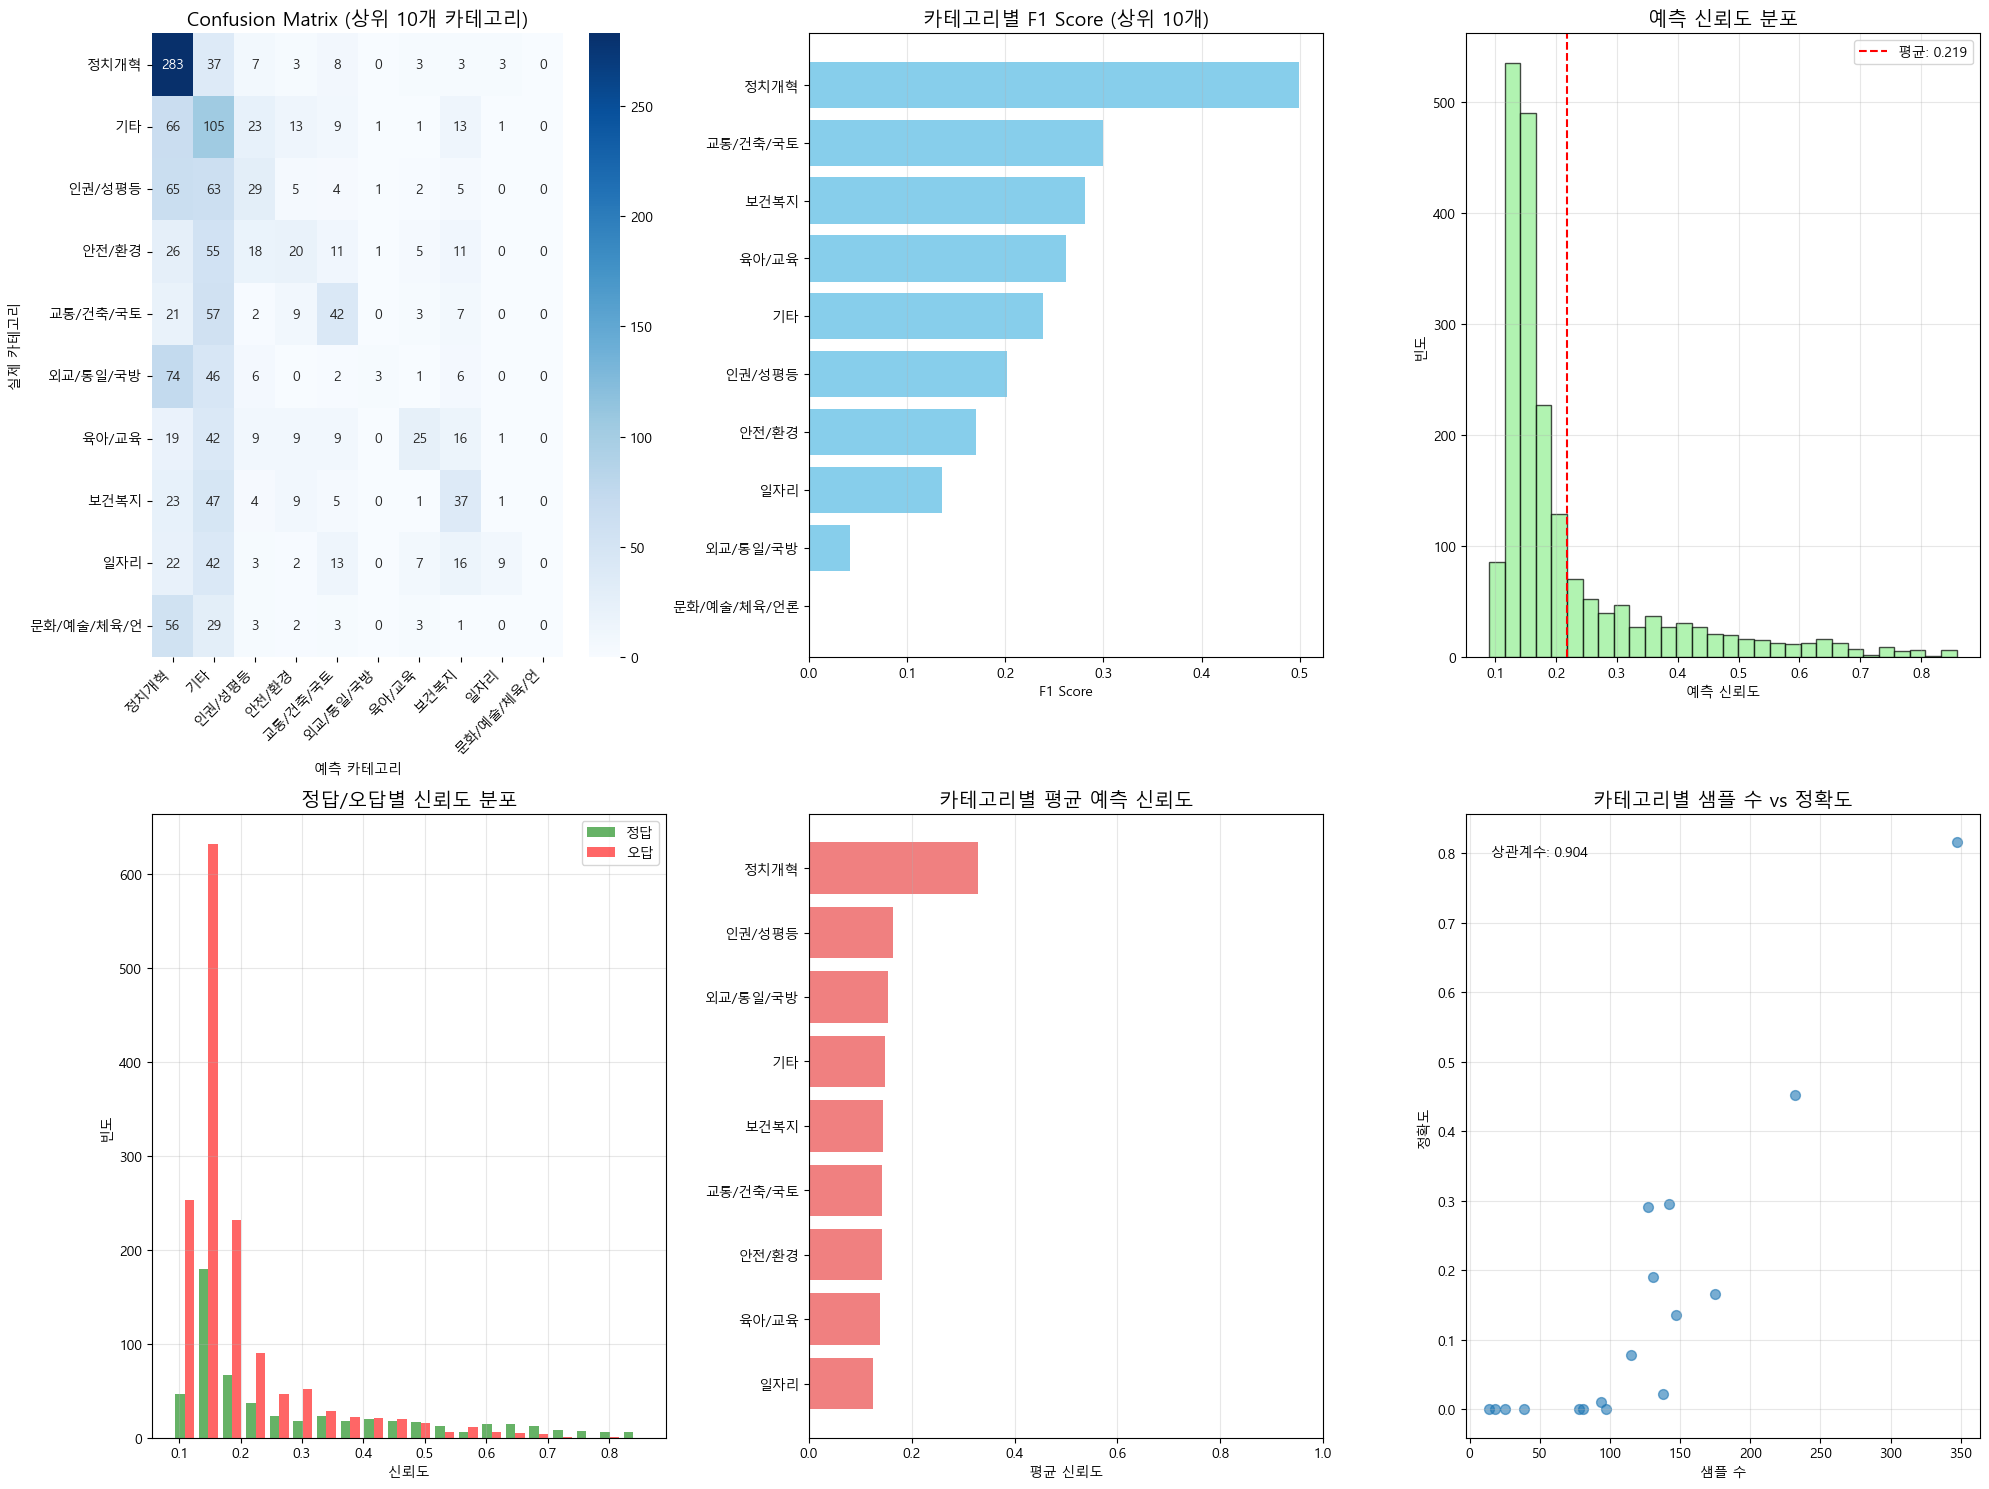

In [29]:
# ============================================
# Cell 7: 결과 시각화
# ============================================

print("\n" + "="*50)
print("6. 결과 시각화")
print("="*50)

# 6개의 서브플롯으로 다양한 측면 시각화
fig = plt.figure(figsize=(20, 15))

# 1. Confusion Matrix (혼동 행렬) - 상위 10개 카테고리
ax1 = plt.subplot(2, 3, 1)
# 가장 빈번한 10개 카테고리만 선택 (전체는 너무 복잡)
top_categories_idx = pd.Series(y_test_sample).value_counts().head(10).index.tolist()
mask = np.isin(y_test_sample, top_categories_idx) & np.isin(y_pred, top_categories_idx)

if mask.sum() > 0:
    # 혼동 행렬 계산
    cm = confusion_matrix(y_test_sample[mask], np.array(y_pred)[mask], labels=top_categories_idx)
    # 히트맵으로 시각화
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=[id_to_category[str(i)][:10] for i in top_categories_idx],
                yticklabels=[id_to_category[str(i)][:10] for i in top_categories_idx],
                ax=ax1)
    ax1.set_title('Confusion Matrix (상위 10개 카테고리)', fontsize=14)
    ax1.set_xlabel('예측 카테고리')
    ax1.set_ylabel('실제 카테고리')
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
# 대각선이 진할수록 정확도가 높음

# 2. 카테고리별 F1 Score
ax2 = plt.subplot(2, 3, 2)
category_f1_scores = []
for cat_idx in top_categories_idx:
    mask = y_test_sample == cat_idx
    if mask.sum() > 0:
        # 해당 카테고리를 양성(1), 나머지를 음성(0)으로 변환
        y_binary = (y_test_sample == cat_idx).astype(int)
        pred_binary = (np.array(y_pred) == cat_idx).astype(int)
        f1_val = f1_score(y_binary, pred_binary, average='binary')
        category_f1_scores.append((id_to_category[str(cat_idx)], f1_val))

if category_f1_scores:
    # F1 score 기준으로 정렬
    cat_names, f1_scores = zip(*sorted(category_f1_scores, key=lambda x: x[1]))
    y_pos = np.arange(len(cat_names))
    ax2.barh(y_pos, f1_scores, color='skyblue')
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels([name[:15] for name in cat_names])
    ax2.set_xlabel('F1 Score')
    ax2.set_title('카테고리별 F1 Score (상위 10개)', fontsize=14)
    ax2.grid(True, alpha=0.3, axis='x')

# 3. 신뢰도 분포
ax3 = plt.subplot(2, 3, 3)
ax3.hist(confidences, bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
ax3.axvline(np.mean(confidences), color='red', linestyle='--', 
            label=f'평균: {np.mean(confidences):.3f}')
ax3.set_xlabel('예측 신뢰도')
ax3.set_ylabel('빈도')
ax3.set_title('예측 신뢰도 분포', fontsize=14)
ax3.legend()
ax3.grid(True, alpha=0.3)
# 신뢰도가 높을수록 모델이 확신을 가지고 예측

# 4. 정답 vs 오답의 신뢰도 비교
ax4 = plt.subplot(2, 3, 4)
correct_mask = np.array(y_pred) == y_test_sample
correct_conf = np.array(confidences)[correct_mask]  # 정답의 신뢰도
incorrect_conf = np.array(confidences)[~correct_mask]  # 오답의 신뢰도

if len(correct_conf) > 0 and len(incorrect_conf) > 0:
    ax4.hist([correct_conf, incorrect_conf], bins=20, label=['정답', '오답'], 
             color=['green', 'red'], alpha=0.6)
    ax4.set_xlabel('신뢰도')
    ax4.set_ylabel('빈도')
    ax4.set_title('정답/오답별 신뢰도 분포', fontsize=14)
    ax4.legend()
    ax4.grid(True, alpha=0.3)
# 정답의 신뢰도가 오답보다 높으면 모델이 잘 학습됨

# 5. 카테고리별 평균 신뢰도
ax5 = plt.subplot(2, 3, 5)
category_confidences = {}
for cat_idx in top_categories_idx:
    mask = np.array(y_pred) == cat_idx
    if mask.sum() > 0:
        category_confidences[id_to_category[str(cat_idx)]] = np.mean(np.array(confidences)[mask])

if category_confidences:
    sorted_cats = sorted(category_confidences.items(), key=lambda x: x[1])
    cat_names, avg_confs = zip(*sorted_cats)
    y_pos = np.arange(len(cat_names))
    ax5.barh(y_pos, avg_confs, color='lightcoral')
    ax5.set_yticks(y_pos)
    ax5.set_yticklabels([name[:15] for name in cat_names])
    ax5.set_xlabel('평균 신뢰도')
    ax5.set_title('카테고리별 평균 예측 신뢰도', fontsize=14)
    ax5.set_xlim(0, 1)
    ax5.grid(True, alpha=0.3, axis='x')
# 특정 카테고리가 다른 카테고리보다 예측하기 어려운지 확인

# 6. 샘플 수 vs 정확도
ax6 = plt.subplot(2, 3, 6)
category_accuracy = []
for cat_idx in range(len(categories)):
    mask = y_test_sample == cat_idx
    if mask.sum() >= 10:  # 최소 10개 이상의 샘플이 있는 경우만
        cat_pred = np.array(y_pred)[mask]
        cat_true = y_test_sample[mask]
        acc = accuracy_score(cat_true, cat_pred)
        category_accuracy.append((mask.sum(), acc, id_to_category[str(cat_idx)]))

if category_accuracy:
    sample_counts, accuracies, cat_names = zip(*category_accuracy)
    scatter = ax6.scatter(sample_counts, accuracies, alpha=0.6, s=50)
    ax6.set_xlabel('샘플 수')
    ax6.set_ylabel('정확도')
    ax6.set_title('카테고리별 샘플 수 vs 정확도', fontsize=14)
    ax6.grid(True, alpha=0.3)
    
    # 상관관계 계산 및 표시
    if pearsonr and len(sample_counts) > 3:
        corr, _ = pearsonr(sample_counts, accuracies)
        ax6.text(0.05, 0.95, f'상관계수: {corr:.3f}', 
                transform=ax6.transAxes, verticalalignment='top')
# 샘플 수가 많을수록 정확도가 높은지 확인

plt.tight_layout()
plt.show()

In [30]:
# ============================================
# Cell 8: 오분류 분석
# ============================================

print("\n" + "="*50)
print("7. 오분류 분석")
print("="*50)

# 오분류된 샘플 찾기
misclassified_indices = np.where(np.array(y_pred) != y_test_sample)[0]
print(f"오분류된 샘플 수: {len(misclassified_indices)}개 ({len(misclassified_indices)/len(y_test_sample)*100:.1f}%)")

# 오분류 패턴 분석
misclass_patterns = {}
for idx in misclassified_indices:
    true_cat = id_to_category[str(y_test_sample[idx])]
    pred_cat = id_to_category[str(y_pred[idx])]
    pattern = f"{true_cat} → {pred_cat}"
    misclass_patterns[pattern] = misclass_patterns.get(pattern, 0) + 1

# 가장 빈번한 오분류 패턴
print("\n가장 빈번한 오분류 패턴 (상위 10개):")
sorted_patterns = sorted(misclass_patterns.items(), key=lambda x: x[1], reverse=True)[:10]
for pattern, count in sorted_patterns:
    print(f"  {pattern}: {count}회")
# 어떤 카테고리들이 서로 혼동되는지 파악

# 오분류 샘플 예시
print("\n오분류 샘플 예시 (5개):")
for i, idx in enumerate(misclassified_indices[:5]):
    text = X_test_sample[idx]
    true_cat = id_to_category[str(y_test_sample[idx])]
    pred_cat = id_to_category[str(y_pred[idx])]
    conf = confidences[idx]
    
    # 제목 추출 (첫 [SEP] 이전 부분)
    title = text.split(' [SEP] ')[0] if ' [SEP] ' in text else text[:100]
    
    print(f"\n{i+1}. 제목: {title}")
    print(f"   실제: {true_cat}")
    print(f"   예측: {pred_cat} (신뢰도: {conf:.3f})")
# 실제 오분류 사례를 보고 개선점 파악


7. 오분류 분석
오분류된 샘플 수: 1446개 (72.3%)

가장 빈번한 오분류 패턴 (상위 10개):
  외교/통일/국방 → 정치개혁: 74회
  기타 → 정치개혁: 66회
  인권/성평등 → 정치개혁: 65회
  인권/성평등 → 기타: 63회
  교통/건축/국토 → 기타: 57회
  문화/예술/체육/언론 → 정치개혁: 56회
  안전/환경 → 기타: 55회
  보건복지 → 기타: 47회
  외교/통일/국방 → 기타: 46회
  일자리 → 기타: 42회

오분류 샘플 예시 (5개):

1. 제목: 층간소음 !!! 혁신적 으로, 개선하라 !!!!!! 촛불의 명령 이다 !!!!!!!!!
   실제: 인권/성평등
   예측: 정치개혁 (신뢰도: 0.487)

2. 제목: 서민대출
   실제: 기타
   예측: 일자리 (신뢰도: 0.156)

3. 제목: 집값 담합에 앞장서는 아파트 인터넷 커뮤니티 처벌해  주세요!
   실제: 교통/건축/국토
   예측: 기타 (신뢰도: 0.168)

4. 제목: 동의합니다
   실제: 기타
   예측: 인권/성평등 (신뢰도: 0.243)

5. 제목: 대법원의양심적병역거부자판결대하에
   실제: 외교/통일/국방
   예측: 정치개혁 (신뢰도: 0.268)


In [31]:
# ============================================
# Cell 9: 실시간 분류 테스트
# ============================================

print("\n" + "="*50)
print("8. 실시간 분류 테스트")
print("="*50)

# 실제 데이터에서 랜덤하게 5개 선택하여 테스트
demo_indices = np.random.choice(len(df), 5, replace=False)
demo_samples = df.iloc[demo_indices]

print("실제 청원 데이터 분류 예시:\n")
for idx, row in demo_samples.iterrows():
    title = row['title']
    content = row['content'][:200] + "..." if len(row['content']) > 200 else row['content']
    true_category = row['category']
    
    # 예측 수행
    pred_category, confidence, probs = predict_category(row['text'], return_probs=True)
    
    print(f"제목: {title}")
    print(f"내용: {content}")
    print(f"실제 카테고리: {true_category}")
    print(f"예측 카테고리: {pred_category} (신뢰도: {confidence:.2%})")
    
    # 상위 3개 카테고리와 확률 표시
    sorted_probs = sorted(probs.items(), key=lambda x: x[1], reverse=True)[:3]
    print("상위 3개 예측:")
    for cat, prob in sorted_probs:
        print(f"  - {cat}: {prob:.2%}")
    
    # 정답 여부 표시
    if pred_category == true_category:
        print("[정답]")
    else:
        print("[오답]")
    print("-" * 80)


8. 실시간 분류 테스트
실제 청원 데이터 분류 예시:

제목: 현재 법으로면, 자전거 사고 내면 무조건 도망가세요.
내용: 일시 2019년 4월30일 시간 오후 5시경 장소 국회의사당에서 자전거 도로 진입로 여의도 미리나 선착장근처 산책로 50대의 검은 옷에 검은 두건에 선글라스까지 써서 얼굴이 하나도 안보이는 아저씨가 산책로를 걷고있는 70대의 저희 아버지를 자전거로 치어놓고 쓰러져 아파하고 있는 사람에게 '빨리 일어나요!' 이렇게 소리를 짜증스럽게 지르고서는 확 가버렸답니다...
실제 카테고리: 안전/환경
예측 카테고리: 기타 (신뢰도: 14.60%)
상위 3개 예측:
  - 기타: 14.60%
  - 교통/건축/국토: 12.05%
  - 안전/환경: 10.73%
[오답]
--------------------------------------------------------------------------------
제목: 비양심적인 시민들만 애용하는 지하철 핑크카펫 철수해야....
내용: 아무리 좋은 취지로 마련된 정책도 실제 역효과가 많으면 철회하는 것이 바람직하다고 생각합니다. 지하철 내에 임산부 전용 핑크카펫은 그 취지는 매우 훌륭하였으나, 실제로는 비양심적인 시민의 모습만 목격하게 되는 아주 불편한 자리로 변질되고 말았습니다. 실제 임산부들이 앉는 경우는 드물고, 학생, 청년, 중장년층 불문하고 뻔뻔하게 앉아 있는 경우가 대부분입니다...
실제 카테고리: 교통/건축/국토
예측 카테고리: 안전/환경 (신뢰도: 12.37%)
상위 3개 예측:
  - 안전/환경: 12.37%
  - 인권/성평등: 11.51%
  - 기타: 10.66%
[오답]
--------------------------------------------------------------------------------
제목: 협동조합 조합장 연임제도 개선 희망합니다ㆍ
내용: 지금현재 협동조합 선거는 전국동시선거를 통하여 선출하고 있으나,상임조합장과 비상임조합장으로 구분하여 상임은 2


9. 카테고리별 성능 평가


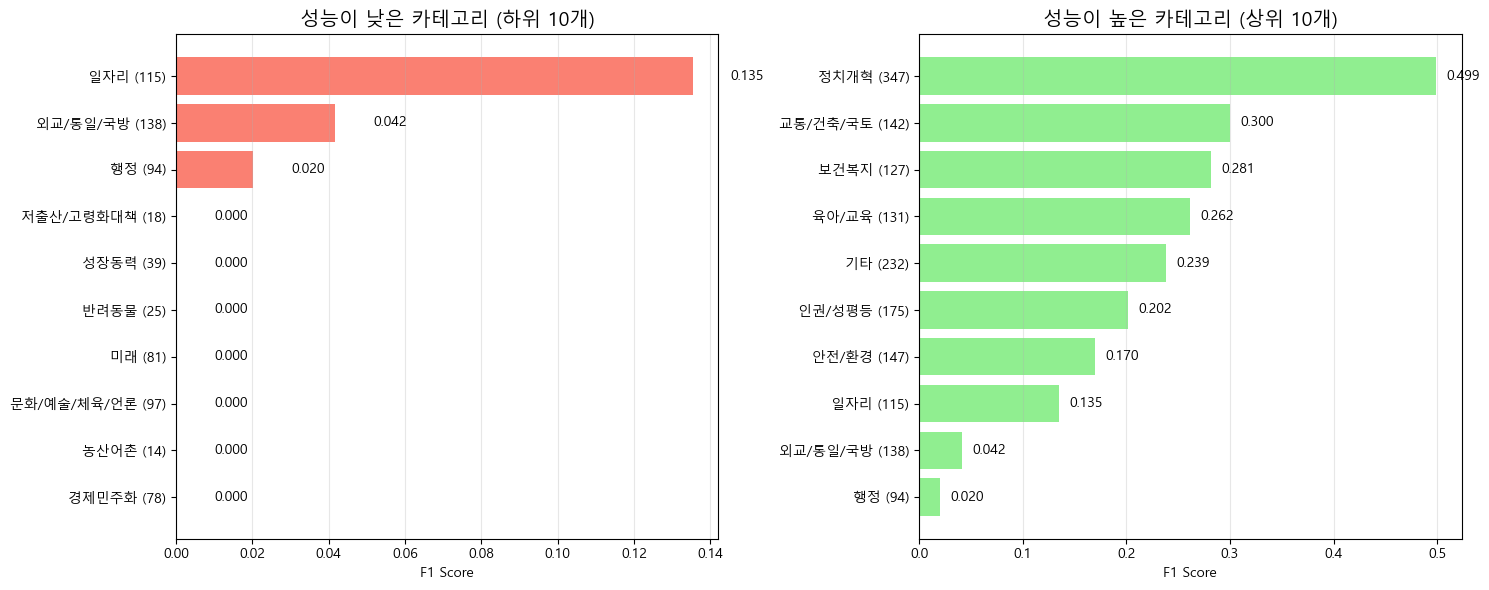

In [32]:
# ============================================
# Cell 10: 카테고리별 성능 평가 및 시각화
# ============================================

print("\n" + "="*50)
print("9. 카테고리별 성능 평가")
print("="*50)

# 모든 카테고리의 F1 Score 계산
all_category_f1 = []
for cat_id in range(len(categories)):
    mask = y_test_sample == cat_id
    if mask.sum() >= 5:  # 최소 5개 샘플이 있는 경우만
        # 이진 분류로 변환
        y_binary = (y_test_sample == cat_id).astype(int)
        pred_binary = (np.array(y_pred) == cat_id).astype(int)
        
        # 성능 지표 계산
        precision, recall, f1_val, support = precision_recall_fscore_support(
            y_binary, pred_binary, average='binary', zero_division=0
        )
        all_category_f1.append((id_to_category[str(cat_id)], f1_val, mask.sum()))

# F1 Score 기준으로 정렬
all_category_f1.sort(key=lambda x: x[1])

# 상위/하위 성능 카테고리 시각화
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 하위 10개 (성능이 낮은 카테고리)
bottom_10 = all_category_f1[:10]
if bottom_10:
    categories_b, f1s_b, counts_b = zip(*bottom_10)
    y_pos = np.arange(len(categories_b))
    bars = ax1.barh(y_pos, f1s_b, color='salmon')
    ax1.set_yticks(y_pos)
    ax1.set_yticklabels([f"{cat[:15]} ({cnt})" for cat, cnt in zip(categories_b, counts_b)])
    ax1.set_xlabel('F1 Score')
    ax1.set_title('성능이 낮은 카테고리 (하위 10개)', fontsize=14)
    ax1.grid(True, alpha=0.3, axis='x')
    
    # 막대 위에 값 표시
    for i, (bar, f1_val) in enumerate(zip(bars, f1s_b)):
        ax1.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
                f'{f1_val:.3f}', va='center')

# 상위 10개 (성능이 높은 카테고리)
top_10 = all_category_f1[-10:]
if top_10:
    categories_t, f1s_t, counts_t = zip(*top_10)
    y_pos = np.arange(len(categories_t))
    bars = ax2.barh(y_pos, f1s_t, color='lightgreen')
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels([f"{cat[:15]} ({cnt})" for cat, cnt in zip(categories_t, counts_t)])
    ax2.set_xlabel('F1 Score')
    ax2.set_title('성능이 높은 카테고리 (상위 10개)', fontsize=14)
    ax2.grid(True, alpha=0.3, axis='x')
    
    # 막대 위에 값 표시
    for i, (bar, f1_val) in enumerate(zip(bars, f1s_t)):
        ax2.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
                f'{f1_val:.3f}', va='center')

plt.tight_layout()
plt.show()

In [33]:
# ============================================
# Cell 11: 최종 성능 평가 결과 출력
# ============================================

print("\n" + "="*50)
print("최종 성능 평가 결과")
print("="*50)

# 최종 성능 요약
print(f"""
모델 성능 평가 완료
----------------------------------------
평가 샘플 수: {len(y_test_sample):,}개
정확도 (Accuracy): {accuracy:.4f}
정밀도 (Precision): {precision:.4f}
재현율 (Recall): {recall:.4f}
F1 점수 (F1 Score): {f1:.4f}
평균 예측 신뢰도: {np.mean(confidences):.4f}
오분류율: {len(misclassified_indices)/len(y_test_sample)*100:.1f}%
----------------------------------------
""")

# 카테고리별 성능 요약
if all_category_f1:
    print("카테고리별 성능 (F1 Score 기준):")
    print(f"  최고 성능: {top_10[-1][0]} (F1: {top_10[-1][1]:.3f})")
    print(f"  최저 성능: {bottom_10[0][0]} (F1: {bottom_10[0][1]:.3f})")
    print(f"  평균 F1 Score: {np.mean([f1_val for _, f1_val, _ in all_category_f1]):.3f}")

print("\n평가 완료!")


최종 성능 평가 결과

모델 성능 평가 완료
----------------------------------------
평가 샘플 수: 2,000개
정확도 (Accuracy): 0.2770
정밀도 (Precision): 0.2000
재현율 (Recall): 0.0106
F1 점수 (F1 Score): 0.2123
평균 예측 신뢰도: 0.2188
오분류율: 72.3%
----------------------------------------

카테고리별 성능 (F1 Score 기준):
  최고 성능: 정치개혁 (F1: 0.499)
  최저 성능: 경제민주화 (F1: 0.000)
  평균 F1 Score: 0.126

평가 완료!
